
# Momentum Gradient Descent Demo

This notebook demonstrates:

1. A simple neural network / linear model
2. Gradient Descent vs Momentum Gradient Descent
3. Optimization trajectories
4. Loss surface contour plots 



In [216]:

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)



## Create Synthetic Dataset

We generate simple linear data:

\[ y = 2x + 1 + noise \]


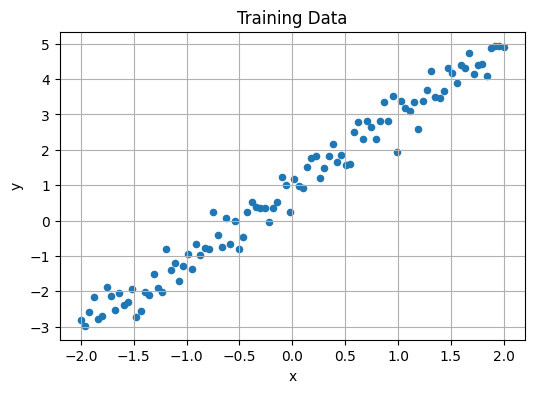

In [217]:

X = np.linspace(-2, 2, 100)
noise = np.random.normal(0, 0.4, size=X.shape)
Y = 2 * X + 1 + noise

plt.figure(figsize=(6,4))
plt.scatter(X, Y, s=20)
plt.title("Training Data")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()



## Model

Simple linear model:

\[ \hat y = wx + b \]

Loss function:

\[
L(w,b) = \frac{1}{n}\sum (\hat y - y)^2
\]


In [218]:

def predict(w, b, x):
    return w * x + b

def loss(w, b, X, Y):
    y_hat = predict(w, b, X)
    return np.mean((y_hat - Y) ** 2)

def gradients(w, b, X, Y):
    n = len(X)
    y_hat = predict(w, b, X)

    dw = (2/n) * np.sum((y_hat - Y) * X)
    db = (2/n) * np.sum(y_hat - Y)

    return dw, db



# Normal Gradient Descent


In [219]:

def gradient_descent(X, Y, lr=0.05, epochs=50):
    w, b = -4, 4

    path = []

    for _ in range(epochs):
        dw, db = gradients(w, b, X, Y)

        w = w - lr * dw
        b = b - lr * db

        path.append((w, b, loss(w, b, X, Y)))

    return w, b, path

w_gd, b_gd, path_gd = gradient_descent(X, Y)

print("GD final parameters")
print("w =", w_gd)
print("b =", b_gd)


GD final parameters
w = 2.0097738913770007
b = 0.9741367993070078



# Momentum Gradient Descent

Momentum update:

\[
v_t = \gamma v_{t-1} + \eta \nabla J
\]

\[
\theta = \theta - v_t
\]

Where:

- \(\gamma\) = momentum coefficient
- \(\eta\) = learning rate


In [220]:

def momentum_gradient_descent(X, Y, lr=0.05, gamma=0.75, epochs=50):

    w, b = -4, 4

    vw, vb = 0, 0

    path = []

    for _ in range(epochs):

        dw, db = gradients(w, b, X, Y)

        vw = gamma * vw + dw
        vb = gamma * vb + db

        w = w - lr * vw
        b = b - lr * vb

        path.append((w, b, loss(w, b, X, Y)))

    return w, b, path

w_m, b_m, path_m = momentum_gradient_descent(X, Y)

print("Momentum GD final parameters")
print("w =", w_m)
print("b =", b_m)


Momentum GD final parameters
w = 2.0096718882679774
b = 0.9564124745356739



# Compare Loss Curves


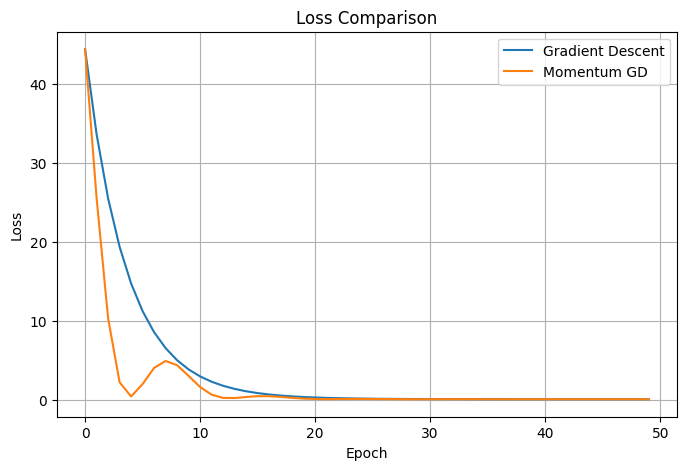

In [221]:

losses_gd = [p[2] for p in path_gd]
losses_m = [p[2] for p in path_m]

plt.figure(figsize=(8,5))

plt.plot(losses_gd, label="Gradient Descent")
plt.plot(losses_m, label="Momentum GD")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Comparison")
plt.legend()
plt.grid(True)

plt.show()



# Generate Loss Surface


In [222]:

w_vals = np.linspace(-5, 5, 120)
b_vals = np.linspace(-5, 5, 120)

W, B = np.meshgrid(w_vals, b_vals)

Z = np.zeros_like(W)

for i in range(W.shape[0]):
    for j in range(W.shape[1]):
        Z[i, j] = loss(W[i, j], B[i, j], X, Y)



# Plot Optimization Paths


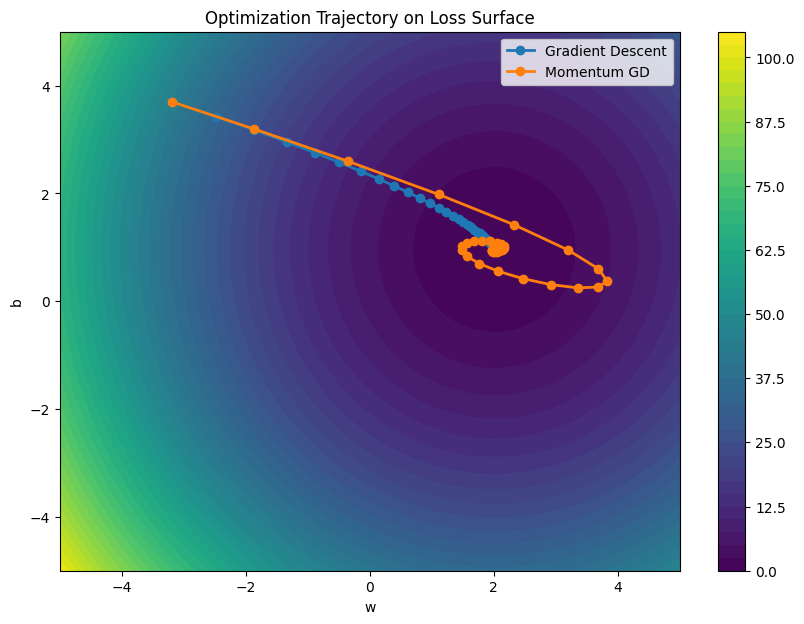

In [223]:

gd_w = [p[0] for p in path_gd]
gd_b = [p[1] for p in path_gd]

m_w = [p[0] for p in path_m]
m_b = [p[1] for p in path_m]

plt.figure(figsize=(10,7))

contours = plt.contourf(W, B, Z, levels=50)
plt.colorbar(contours)

plt.plot(gd_w, gd_b, 'o-', label='Gradient Descent', linewidth=2)
plt.plot(m_w, m_b, 'o-', label='Momentum GD', linewidth=2)

plt.xlabel("w")
plt.ylabel("b")
plt.title("Optimization Trajectory on Loss Surface")

plt.legend()
plt.show()



# Observe

- Normal Gradient Descent zig-zags more
- Momentum Gradient Descent moves smoother
- Momentum converges faster
- Momentum reduces oscillations



# Additional Optimizers

The next cells demonstrate Nesterov accelerated gradient descent, stochastic gradient descent, mini-batch gradient descent, and Adam on the same linear regression problem.


In [224]:

def nesterov_gradient_descent(X, Y, lr=0.05, gamma=0.75, epochs=50):
    w, b = -4, 4
    vw, vb = 0, 0
    path = []

    for _ in range(epochs):
        lookahead_w = w - gamma * vw
        lookahead_b = b - gamma * vb
        dw, db = gradients(lookahead_w, lookahead_b, X, Y)

        vw = gamma * vw + lr * dw
        vb = gamma * vb + lr * db

        w = w - vw
        b = b - vb

        path.append((w, b, loss(w, b, X, Y)))

    return w, b, path


def stochastic_gradient_descent(X, Y, lr=0.05, epochs=50):
    w, b = -4, 4
    path = []

    for _ in range(epochs):
        indices = np.random.permutation(len(X))

        for index in indices:
            dw, db = gradients(w, b, X[index:index + 1], Y[index:index + 1])
            w = w - lr * dw
            b = b - lr * db

        path.append((w, b, loss(w, b, X, Y)))

    return w, b, path


def mini_batch_gradient_descent(X, Y, lr=0.05, batch_size=16, epochs=50):
    w, b = -4, 4
    path = []

    for _ in range(epochs):
        indices = np.random.permutation(len(X))
        shuffled_X = X[indices]
        shuffled_Y = Y[indices]

        for start in range(0, len(X), batch_size):
            xb = shuffled_X[start:start + batch_size]
            yb = shuffled_Y[start:start + batch_size]
            dw, db = gradients(w, b, xb, yb)
            w = w - lr * dw
            b = b - lr * db

        path.append((w, b, loss(w, b, X, Y)))

    return w, b, path


def adam_optimizer(X, Y, lr=0.05, beta1=0.7, beta2=0.9, epsilon=1e-8, epochs=100):
    w, b = -4, 4
    mw, mb = 0, 0
    vw, vb = 0, 0
    path = []

    for step in range(1, epochs + 1):
        dw, db = gradients(w, b, X, Y)

        mw = beta1 * mw + (1 - beta1) * dw
        mb = beta1 * mb + (1 - beta1) * db
        vw = beta2 * vw + (1 - beta2) * (dw ** 2)
        vb = beta2 * vb + (1 - beta2) * (db ** 2)

        mw_hat = mw / (1 - beta1 ** step)
        mb_hat = mb / (1 - beta1 ** step)
        vw_hat = vw / (1 - beta2 ** step)
        vb_hat = vb / (1 - beta2 ** step)

        w = w - lr * mw_hat / (np.sqrt(vw_hat) + epsilon)
        b = b - lr * mb_hat / (np.sqrt(vb_hat) + epsilon)

        path.append((w, b, loss(w, b, X, Y)))

    return w, b, path


w_n, b_n, path_n = nesterov_gradient_descent(X, Y)
w_sgd, b_sgd, path_sgd = stochastic_gradient_descent(X, Y)
w_mb, b_mb, path_mb = mini_batch_gradient_descent(X, Y)
w_adam, b_adam, path_adam = adam_optimizer(X, Y)

print("Nesterov final parameters")
print("w =", w_n)
print("b =", b_n)
print()
print("Stochastic GD final parameters")
print("w =", w_sgd)
print("b =", b_sgd)
print()
print("Mini-batch GD final parameters")
print("w =", w_mb)
print("b =", b_mb)
print()
print("Adam final parameters")
print("w =", w_adam)
print("b =", b_adam)


Nesterov final parameters
w = 2.013807839108004
b = 0.9584854567468221

Stochastic GD final parameters
w = 1.9686988763687578
b = 1.0389236497110144

Mini-batch GD final parameters
w = 2.0390310566570626
b = 0.9619666515109155

Adam final parameters
w = 0.5989940680476566
b = 0.9596477204180995


### Loss Comparison

This plot compares the convergence behavior of all optimizers on the same dataset.


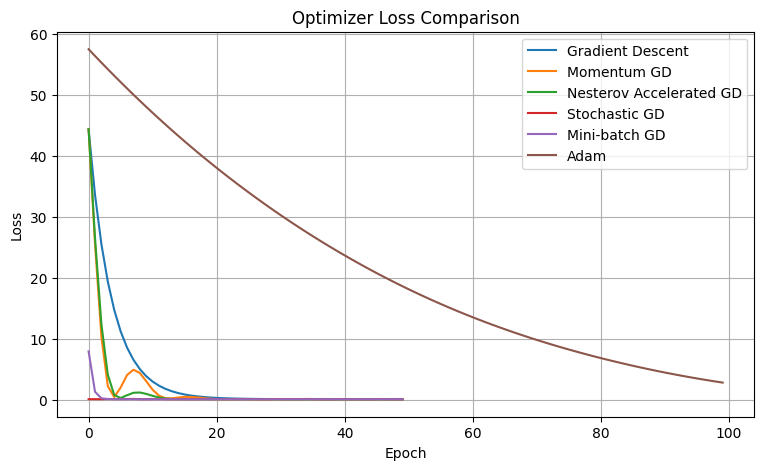

In [225]:

losses_n = [p[2] for p in path_n]
losses_sgd = [p[2] for p in path_sgd]
losses_mb = [p[2] for p in path_mb]
losses_adam = [p[2] for p in path_adam]

plt.figure(figsize=(9, 5))

plt.plot(losses_gd, label="Gradient Descent")
plt.plot(losses_m, label="Momentum GD")
plt.plot(losses_n, label="Nesterov Accelerated GD")
plt.plot(losses_sgd, label="Stochastic GD")
plt.plot(losses_mb, label="Mini-batch GD")
plt.plot(losses_adam, label="Adam")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Optimizer Loss Comparison")
plt.legend()
plt.grid(True)
plt.show()


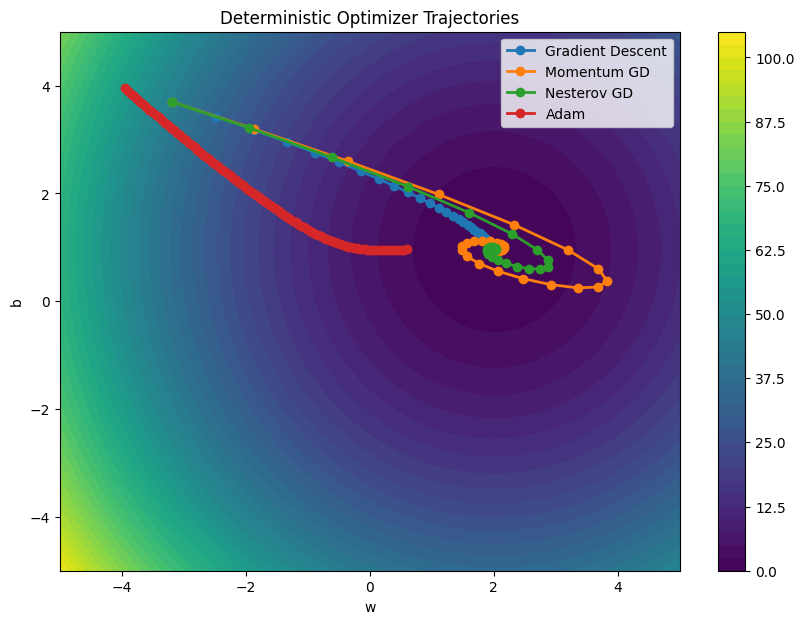

In [226]:

gd_w = [p[0] for p in path_gd]
gd_b = [p[1] for p in path_gd]

m_w = [p[0] for p in path_m]
m_b = [p[1] for p in path_m]

n_w = [p[0] for p in path_n]
n_b = [p[1] for p in path_n]

adam_w = [p[0] for p in path_adam]
adam_b = [p[1] for p in path_adam]

plt.figure(figsize=(10, 7))
contours = plt.contourf(W, B, Z, levels=50)
plt.colorbar(contours)

plt.plot(gd_w, gd_b, 'o-', label='Gradient Descent', linewidth=2)
plt.plot(m_w, m_b, 'o-', label='Momentum GD', linewidth=2)
plt.plot(n_w, n_b, 'o-', label='Nesterov GD', linewidth=2)
plt.plot(adam_w, adam_b, 'o-', label='Adam', linewidth=2)

plt.xlabel("w")
plt.ylabel("b")
plt.title("Deterministic Optimizer Trajectories")
plt.legend()
plt.show()
